The tests have been adjusted from the original proposed tests due to scope. For example, a comparison the Arp 220 empirical data set would be great, but the source positions and luminosities at 1.45 GHz for all ~100 detections were not publically available in an easily readable format. Below are a few relevant but less time intensive tests.

In [12]:
# import neccesary packages here
import numpy as np
from source import *

**Test 1:**

When we randomly sample our source positions, it should converge to the function after a large number of samples ($\sim1/\sqrt{N}$ test). Our first test will be to confirm this. 

Consider a gaussian distribution centered about N/2 with a standard deviation of N/6. For N = 600, this corresponds to a mean position of 300 and a standard deviation of 100. 

We calculate the positions for a range of rates and determine the mean and standard deviation of the positions.

In [13]:
rates = np.arange(0.1, 30, step=0.1)
mu = np.array([])
sigma = np.array([])

for rate in rates:
    pop = SNe_pop(rate)
    pop.position(N=600, dist='gauss')
    sigma = np.append(sigma, np.std(pop.x))
    mu = np.append(mu, np.mean(pop.x))

So how does the fit evolve as we increase the sample size? (i.e., the rate?)?

Text(0, 0.5, 'Mean position')

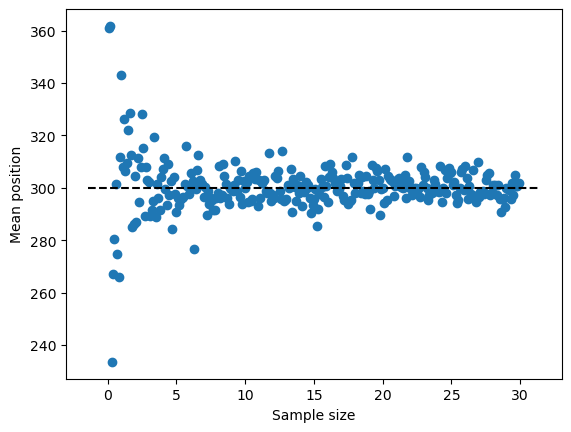

In [14]:
plt.scatter(rates, mu)

xmin, xmax = plt.xlim()
plt.hlines(300, xmin, xmax, linestyles = 'dashed', colors='k')
plt.xlabel('Sample size')
plt.ylabel('Mean position')

Text(0, 0.5, 'Standard deviation')

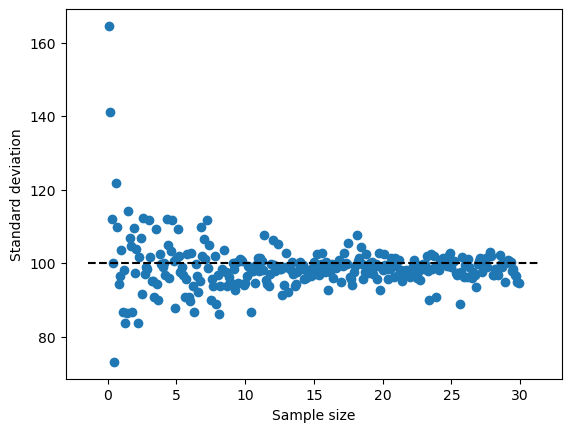

In [15]:
plt.scatter(rates, sigma)

xmin, xmax = plt.xlim()
plt.hlines(100, xmin, xmax, linestyles = 'dashed', colors='k')
plt.xlabel('Sample size')
plt.ylabel('Standard deviation')

We can also visualize this by measuring the exact error between the predicted and observed mean and standard deviation:

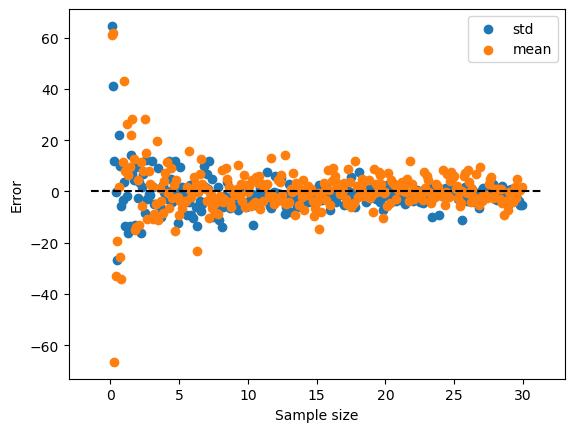

In [16]:
plt.scatter(rates, sigma-100, label='std')
plt.scatter(rates, mu-300, label='mean')

xmin, xmax = plt.xlim()
plt.hlines(0, xmin, xmax, linestyles = 'dashed', colors='k')
plt.xlabel('Sample size')
plt.ylabel('Error')
plt.legend()

We observe a clear convergence as the sample size increases.

**Test 2**

Here, we test the outputs at two extremes (Tests 2 and 3). For this test, we focus on the output "count." As a reminder, this gives the total number of measurments above the luminosity threshold set by the user. For the first test, if we set the aperture size to the size of the field of view, "count" should never be greater than 1.

We test this for 10,000 iterations. (The runtime should be a mere fraction of the runs in the tutorial because of the large aperture size)

In [17]:
## set our parameters
criteria = -1 ##luminosity threshold set to -1 for simplicity
FOV = 200
radius_pc = FOV/2 #aperture diameter is equal to the FOV

# some other relevant parameters (will not affect the test)
N = 500
rate = 2
step_pc = 1
lumin_range = np.arange(1.5e3, 2e4, 5e2)

In [18]:
%%time

iterations = 1000
n_jobs = 16

total_luminosities, counts, population = run_mc(iterations, n_jobs, rate, radius_pc, lumin_range, criteria, FOV=FOV, 
                                                          N=N, dist='gauss', step_pc=step_pc, savecsv=False)

CPU times: user 9.74 s, sys: 1.73 s, total: 11.5 s
Wall time: 8min 15s


We check if any value is greater than 1. It passes the test.

In [19]:
np.any(np.array(counts) > 1) 

np.False_

**Test 3**

The second extreme we test is if we set the aperture radius to be the pixel size (FOV/N). In this case, the number of measurements should equal to NxN + 2N + 1. We can test this for a range of values for "N", the number of pixels for the NxN sized region modeled in this program. Note even if we set the luminosity threshold to 0 or -1, the "count" output could be lower than the total number of pixels if sources are overlapping. 

To reduce the runtime, we'll set the FOV and "rates" to be fairly low. This still takes ___ on my computer.

In [20]:
%%time

num_measurements = np.array([])

Ns = np.array([5, 10, 20, 30, 40, 50])
criteria = -1 ##luminosity threshold set to a negative number for simplicity

# some other relevant parameters (will not affect the test)
rate = 0.5
FOV = 50
lumin_range = np.arange(1.5e3, 2e4, 5e2)
iterations = 1
n_jobs = 16

for N in Ns:
    radius_pc = FOV/(2*N) #aperture diameter is equal to the FOV (radius is half a pixel)
    step_pc = 2*radius_pc #step_pc must be at least one pixel in size
    
    total_luminosities, counts, population = run_mc(iterations, n_jobs, rate, radius_pc, lumin_range, criteria, FOV=FOV, 
                                                          N=N, dist='gauss', step_pc=step_pc,savecsv=False)
    num_measurements = np.append(num_measurements, len(total_luminosities))

CPU times: user 241 ms, sys: 74.5 ms, total: 316 ms
Wall time: 18.3 s


We can now compare the total number of measurements to the expected amount.

In [21]:
### Expected:

for N in Ns:
    print(N*N+2*N+1)

36
121
441
961
1681
2601


In [22]:
print(num_measurements)

[  36.  121.  441.  961. 1681. 2601.]


It passes the test. The apertures are appropriately sampled throughout the modeled region.